# Analysis of Tags

In [94]:
import torch
import pandas as pd

# requires the data from Zenodo
data = torch.load("data/final/diverse_rich.pt", weights_only=False)

df = pd.DataFrame.from_dict(data["info"], orient="index")
df["dvi"] = df.apply(lambda row: not (row.version in row.filename), axis=1)


## Missing Values

In [95]:
def get_nan_info(df, columns):
    n = len(df)
    for col in columns:
        if col in df.columns:
            if col.startswith("matched_"):
                n_empty = len(df[df[col].apply(len) == 0])
            else:
                n_empty = df[col].isna().sum()
            print(f"{col}: {n_empty:,} missing ({n_empty / n * 100:.2f}% of total {n})")
        
columns = [
    "tempo",
    "matched_tags_multilingual",
]

print("\nNaN info for full dataset")
get_nan_info(df, columns)

print("\nNaN info for DVI dataset")
get_nan_info(df[df.dvi], columns)



NaN info for full dataset
tempo: 7 missing (0.00% of total 1389775)
matched_tags_multilingual: 449,244 missing (32.32% of total 1389775)

NaN info for DVI dataset
tempo: 0 missing (0.00% of total 477572)
matched_tags_multilingual: 200,997 missing (42.09% of total 477572)


## Value Distributions

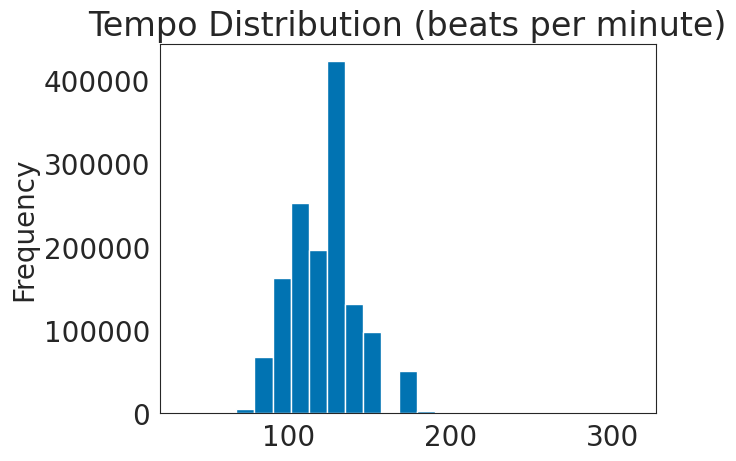

In [96]:
import matplotlib.pyplot as plt

df.tempo.plot(kind="hist", bins=25, title="Tempo Distribution (beats per minute)")
plt.show()


In [97]:
def parse_matched_dict(d):
    if isinstance(d, dict):
        if d == {}:
            return []
        return list({k for sub in d.values() for k in sub.keys()})
    return []

df["Tags"] = df.matched_tags_multilingual.apply(parse_matched_dict)
df["Source"] = df.apply(lambda row: "Discogs (DVI)" if row.dvi else "YouTube (YVI)", axis=1)


In [98]:
ntags = df.Tags.apply(len)
n_no_tags = (ntags == 0).sum()
print(f"{round(n_no_tags/len(ntags)*100,2)}% of items without tags: {n_no_tags:,} out of {len(ntags):,}")
ntags.describe().round(2)


32.37% of items without tags: 449,932 out of 1,389,775


count    1389775.00
mean           2.27
std            3.20
min            0.00
25%            0.00
50%            1.00
75%            3.00
max           47.00
Name: Tags, dtype: float64

Saved PDF: figures/matched_tags.pdf


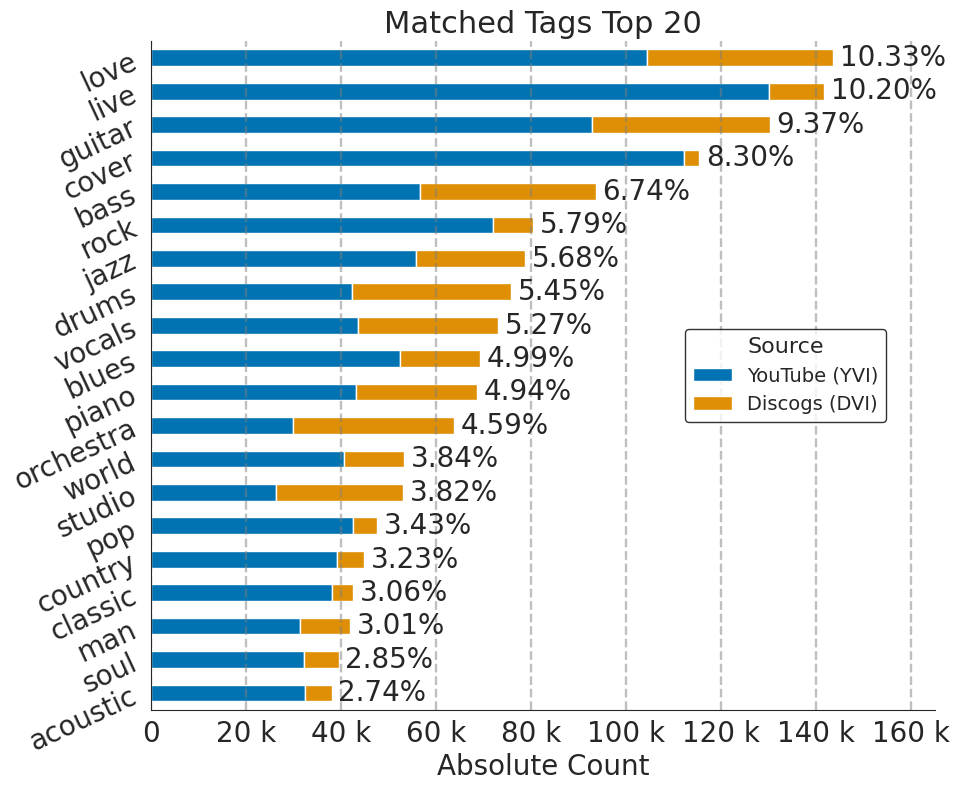

In [99]:
import matplotlib.pyplot as plt
from matplotlib.ticker import EngFormatter
import seaborn as sns

sns.set_palette("colorblind")
sns.set_style(style="white")

def plot_string_counts_barh(df, label_name, top_n=None, out_file=None, hue=None, stacked=True):
    """
    Plot a horizontal bar chart of value counts (absolute and relative) from a Series of lists,
    optionally split (hued) by another column. 
    Percentages and vertical lines are always computed on the overall counts.
    """
    # Explode lists into rows
    exploded = df.explode(label_name)

    if hue is None:
        counts = exploded[label_name].value_counts()
    else:
        counts = exploded.groupby([label_name, hue]).size().unstack(fill_value=0)
        # Reverse column order for stacked bars and legend
        counts = counts[counts.columns[::-1]]

        # Colorblind-friendly palette
        palette = sns.color_palette("colorblind", n_colors=len(counts.columns))
        color_map = {col: palette[i] for i, col in enumerate(counts.columns)}
        colors = [color_map[col] for col in counts.columns]
    # Top-N filtering
    if top_n:
        if hue is None:
            counts = counts.head(top_n)
        else:
            top_labels = counts.sum(axis=1).sort_values(ascending=False).head(top_n).index
            counts = counts.loc[top_labels]

    # Global counts for percentages & vlines
    overall_counts = counts if hue is None else counts.sum(axis=1)
    relative = overall_counts / df.shape[0]

    # Plot
    plt.rcParams.update({'font.size': 20})
    fig, ax = plt.subplots(figsize=(10, 8))
    ax.grid(True, axis='x', linestyle='--', alpha=0.7)

    if hue is None:
        bars = ax.barh(overall_counts.index, overall_counts.values, color='skyblue')
    else:
        counts.plot(kind="barh", stacked=stacked, ax=ax, color=colors)

    # Add vertical lines at xticks
    for xtick in ax.get_xticks():
        ax.axvline(x=xtick, color='gray', linestyle='--', linewidth=1.7, alpha=0.5)

    # Add percentages (based on overall counts)
    max_val = overall_counts.max()
    for i, (abs_val, rel_val) in enumerate(zip(overall_counts.values, relative.values)):
        ax.text(abs_val + max_val * 0.01, i, f"{rel_val:.2%}", va='center', fontsize=20)

    # Formatting
    ax.set_xlim(0, max_val * 1.15)
    ax.xaxis.set_major_formatter(EngFormatter(unit=''))
    ax.set_xlabel("Absolute Count", fontsize=20)
    ax.invert_yaxis()
    plt.yticks(rotation=25)
    plt.ylabel("")

    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

    if hue is not None:
        ax.legend(
            loc='center right',            # anchor the legend to the right side of the axes
            bbox_to_anchor=(0.95, 0.5),    # 0.95 moves it slightly inward (inside)
            frameon=True,                  # add the box back
            edgecolor='black',             # optional: make border visible
            title=hue,
            fontsize=14,
            title_fontsize=16,
        )

    plt.tight_layout()

    if out_file:
        plt.savefig(out_file, format='pdf', bbox_inches='tight')
        print(f"Saved PDF: {out_file}")

    ax.set_title(f"Matched {label_name} Top {top_n}", fontsize=22)
    plt.show()

plot_string_counts_barh(df, "Tags", top_n=20, out_file="figures/matched_tags.pdf", hue="Source", 
                        stacked=True)



## Preparation for manual curation

In [105]:
# Explode lists into rows
exploded = df.explode("Tags")

# Compute tag counts and relative frequencies
n_total = len(df)
df_tag_counts = exploded["Tags"].value_counts().to_frame()
df_tag_counts["relative"] = df_tag_counts["count"] / n_total
df_tag_counts["relative"] = df_tag_counts["relative"].round(2)
df_tag_counts.sort_values("count", ascending=False).head(60)



,count,relative
Tags,,
love,143598,0.10
live,141789,0.10
guitar,130270,0.09
cover,115403,0.08
bass,93632,0.07
rock,80427,0.06
jazz,78890,0.06
drums,75791,0.05
vocals,73172,0.05


## Annotate
To select a subset for annotation we limit to:
- $k$ most frequently occurring tags in the dataset
- our defined content types
    - backingtrack
    - cover
    - karaoke
    - reaction
    - studio
    - tutorial
    - official
- further selected tags
    - solo
    - instrumental
    - acoustic


In [113]:
# collect tags for which we curate
top_k = 15
top_k_tags = df_tag_counts.head(top_k).index.to_list()
content_type_tags = ["backingtrack", "cover", "karaoke", "reaction", "studio", "tutorial", "official"]
additional_tags = ["instrumental", "acoustic", "solo"]
curate_tags = top_k_tags + content_type_tags + additional_tags

# sample n items per tag for manual annotation
n = 100
cols = ['id', 'clique', 'version', 'youtube_id', 'artist', 'title', 'dvi', 'yt_title', 'Tags', 'matched_tags_multilingual']
for tag in curate_tags:
    sample = df.loc[df.Tags.apply(lambda tags: tag in tags), cols].sample(n=n, random_state=42)
    sample.to_csv(f"data/tags/curation/sample{100}_{tag}.csv", index=False)
